# **ІАД**

## **Лаб 2. Кацуба Тимофій КН-42**

In [3]:
!pip install pandas matplotlib seaborn mlxtend

## Попередня обробка даних

In [18]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# чавантаження та підготовка даних
# читаємо файли
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

# об’єднуємо таблиці за movieId
df = pd.merge(ratings, movies, on='movieId')

# залишаємо лише фільми з оцінкою >= 4.0
df_liked = df[df['rating'] >= 4.0]

print("Статистика даних")
print(f"Розмір вихідної таблиці ratings: {ratings.shape}")
print(f"Розмір відфільтрованої таблиці: {df_liked.shape}")
print(f"Унікальних користувачів: {df_liked['userId'].nunique()}")
print(f"Унікальних фільмів: {df_liked['movieId'].nunique()}\n")

# перетворення у транзакційний формат
df_liked['liked'] = 1

# матриця. рядки - користувачі, стовпці - фільми
basket = df_liked.pivot_table(index='userId', columns='title', values='liked', fill_value=0)

# Перетворюємо в логічний тип для алгоритму
basket = basket.astype(bool)

print("Транзакційна матриця")
print("Розмір матриці:", basket.shape)
# Виводимо перші 10 рядків і 10 стовпців для перевірки
display(basket.iloc[:10, :10])

Статистика даних
Розмір вихідної таблиці ratings: (100836, 4)
Розмір відфільтрованої таблиці: (48580, 6)
Унікальних користувачів: 609
Унікальних фільмів: 6298

Транзакційна матриця
Розмір матриці: (609, 6297)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994)
userId,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False


## Пошук частих наборів елементів (Frequent Itemsets) за допомогою алгоритму Apriori

In [19]:
import pandas as pd
from IPython.display import display
from mlxtend.frequent_patterns import apriori

# 1 знаходимо всі часті набори (поріг 0.1)
frequent_itemsets = apriori(basket, min_support=0.1, use_colnames=True)

# 2 рахуємо кількість фільмів у наборі
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# 3 залишаємо лише комбінації (від 2 фільмів)
combinations = frequent_itemsets[frequent_itemsets['length'] >= 2]

# 4 сортуємо за популярністю та беремо топ-10
top_10_combinations = combinations.sort_values(by='support', ascending=False).head(10)

# 5 виводимо  таблицю
pd.set_option('display.max_colwidth', None)
print("Топ-10 найпопулярніших комбінацій фільмів:")
display(top_10_combinations.style.set_table_styles([{'selector': 'table', 'props': [('width', '100%')]}]))

Топ-10 найпопулярніших комбінацій фільмів:


,support,itemsets,length
279,0.275862,"frozenset({'Shawshank Redemption, The (1994)', 'Forrest Gump (1994)'})",2
448,0.259442,"frozenset({'Pulp Fiction (1994)', 'Shawshank Redemption, The (1994)'})",2
449,0.249589,"frozenset({'Silence of the Lambs, The (1991)', 'Pulp Fiction (1994)'})",2
515,0.236453,"frozenset({'Star Wars: Episode IV - A New Hope (1977)', 'Star Wars: Episode V - The Empire Strikes Back (1980)'})",2
495,0.229885,"frozenset({'Silence of the Lambs, The (1991)', 'Shawshank Redemption, The (1994)'})",2
274,0.223317,"frozenset({'Pulp Fiction (1994)', 'Forrest Gump (1994)'})",2
484,0.211823,"frozenset({'Shawshank Redemption, The (1994)', ""Schindler's List (1993)""})",2
281,0.210181,"frozenset({'Silence of the Lambs, The (1991)', 'Forrest Gump (1994)'})",2
411,0.208539,"frozenset({'Matrix, The (1999)', 'Pulp Fiction (1994)'})",2
516,0.206897,"frozenset({'Star Wars: Episode VI - Return of the Jedi (1983)', 'Star Wars: Episode IV - A New Hope (1977)'})",2


## Генерація асоціативних правил (Association Rules) і їх візуалізацію

Топ-10 асоціативних правил за метрикою Lift:


,antecedents,consequents,support,confidence,lift
491,frozenset({Kill Bill: Vol. 1 (2003)}),frozenset({Kill Bill: Vol. 2 (2004)}),0.106732,0.738636,6.247633
490,frozenset({Kill Bill: Vol. 2 (2004)}),frozenset({Kill Bill: Vol. 1 (2003)}),0.106732,0.902778,6.247633
2862,"frozenset({Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981), Star Wars: Episode V - The Empire Strikes Back (1980)})","frozenset({Star Wars: Episode IV - A New Hope (1977), Indiana Jones and the Last Crusade (1989)})",0.106732,0.613208,4.668042
2859,"frozenset({Star Wars: Episode IV - A New Hope (1977), Indiana Jones and the Last Crusade (1989)})","frozenset({Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981), Star Wars: Episode V - The Empire Strikes Back (1980)})",0.106732,0.812500,4.668042
1566,"frozenset({Godfather, The (1972), Goodfellas (1990)})","frozenset({Godfather: Part II, The (1974)})",0.100164,0.792208,4.508921
1567,"frozenset({Godfather: Part II, The (1974)})","frozenset({Godfather, The (1972), Goodfellas (1990)})",0.100164,0.570093,4.508921
2890,"frozenset({Matrix, The (1999), Lord of the Rings: The Two Towers, The (2002)})","frozenset({Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)})",0.123153,0.882353,4.440933
2887,"frozenset({Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)})","frozenset({Matrix, The (1999), Lord of the Rings: The Two Towers, The (2002)})",0.123153,0.619835,4.440933
2634,"frozenset({Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)})","frozenset({Lord of the Rings: The Two Towers, The (2002), Fight Club (1999)})",0.105090,0.528926,4.412544
2639,"frozenset({Lord of the Rings: The Two Towers, The (2002), Fight Club (1999)})","frozenset({Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)})",0.105090,0.876712,4.412544


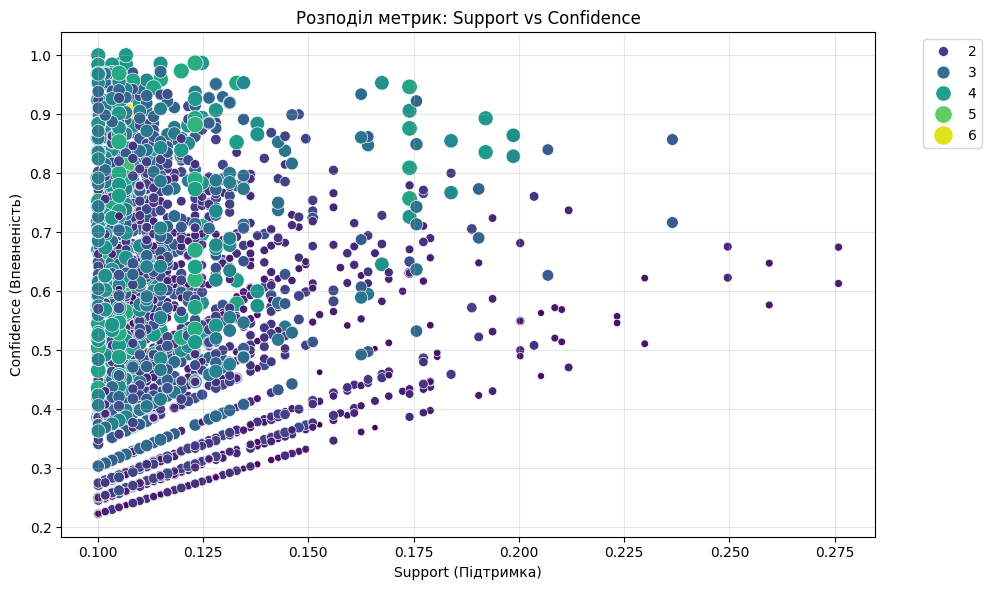

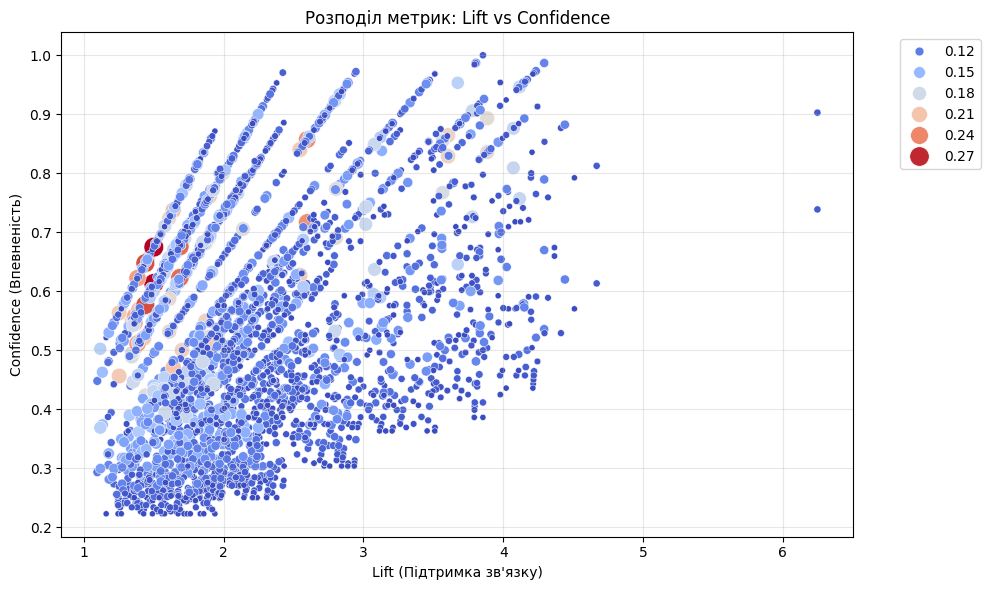

In [20]:
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt
import seaborn as sns

# 1 побудова асоціативних правил
# Використовуємо метрику lift з мінімальним порогом 1.0 (щоб відсіяти фільми, які не пов'язані між собою)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# 2 відсортувати та вивести топ-10 правил за lift
top_10_rules = rules.sort_values(by='lift', ascending=False).head(10)

print("Топ-10 асоціативних правил за метрикою Lift:")
# виводимо лише найважливіші колонки для зручності читання
display(top_10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# 3 візуалізація розподілу метрик

# Support vs Confidence
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x="support", y="confidence", size="lift", hue="lift", palette="viridis", sizes=(20, 200))
plt.title('Розподіл метрик: Support vs Confidence')
plt.xlabel('Support (Підтримка)')
plt.ylabel('Confidence (Впевненість)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Lift vs Confidence
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x="lift", y="confidence", size="support", hue="support", palette="coolwarm", sizes=(20, 200))
plt.title('Розподіл метрик: Lift vs Confidence')
plt.xlabel('Lift (Підтримка зв\'язку)')
plt.ylabel('Confidence (Впевненість)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Висновок:**

Застосування у рекомендаційних системах: Алгоритми пошуку асоціативних правил (такі як Apriori) ідеально підходять для блоку "З цим фільмом також дивляться". На відміну від простого рейтингу популярності, правила враховують контекст. Якщо ми знаємо, що правило Х -> Y має високий confidence та lift, система може автоматично пропонувати фільм Y користувачу, щойно він поставить високу оцінку фільму X.

Вплив параметрів: * Зміна min_support діє як жорсткий фільтр популярності. Якщо поставити його занадто високо (наприклад, 0.3), система знайде лише кілька найпопсовіших блокбастерів, ігноруючи цікаві нішеві фільми. Якщо поставити дуже низько (0.01) — алгоритм знайде багато специфічних правил, але буде працювати експоненційно довше.

Зміна min_confidence впливає на точність рекомендацій. Високий поріг (наприклад, 0.8) залишає лише надійні правила (як-от частини однієї франшизи), але відсіює менш очевидні, проте потенційно корисні для користувача рекомендації. Компроміс між цими параметрами є ключовим для реальних систем.